# Probabilistic forecasting reference notebook

Demonstrates the probabilistic output head (`src/models/heads.py`) and the two
probabilistic losses it enables: `quantile_loss` (pinball loss, aka Quantile
Regression / QR) and `expectile_loss` (asymmetric squared loss, aka Expectile
Regression / ER) — see `src/utils/scores_and_losses.py` and `agents.md`.

Both models are trained to output the full **95% PI down to the 5% PI, in 5%
steps, plus the center** in one shot — 39 channels (`LEVELS` below):
- QR's center channel (level 0.5) is the **median**.
- ER's center channel (level 0.5) is the **mean** (not the median — see
  `ExpectileLoss`'s docstring).
- The `MonotonicHead` every quantile/expectile head uses (see `heads.py`)
  guarantees all 39 channels are non-crossing by construction.

Evaluated with the probabilistic scores — `winkler_score`, `crps`, `scrps`
(Bolin & Wallin's scale-invariant CRPS), `rscrps` (their robust, outlier-clipped
variant of `scrps` — see `RSCRPS`'s docstring), `coverage_gap` (`PICP` minus its
own nominal coverage — 0 is perfectly calibrated, shown throughout as a
percentage), `pinaw` — at the 95% and 75% PI specifically, plus plain `mae`
(which auto-selects the center channel via `_select_point`, whether that's QR's
median or ER's mean).


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.forecaster import Forecaster
from src.models import LSTMHistoric
from src.data import DataSource
from src.data.normalization import _read_1d_df
from src.optim import Adam
from src.utils.scores_and_losses import (
    MAE, QuantileLoss, ExpectileLoss, CRPS, SCRPS, RSCRPS,
    WinklerScore, CoverageGap, PINAW, PICP,
)


## Data setup

Same `DataSource`/column/horizon conventions as `check.ipynb` / `check_rln.ipynb`.

In [2]:
HISTORIC_COLS = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
TARGET_COL    = 'target'
HORIZON       = 7
SEQ_LEN       = 30
NODATA_VALUES = [-999]

train_source = DataSource(
    csv='../data/data.csv',
    start='1980-01-01',
    end='2004-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
val_source = DataSource(
    csv='../data/data.csv',
    start='2005-01-01',
    end='2009-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
test_source = DataSource(
    csv='../data/data.csv',
    start='2010-01-01',
    end='2014-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)

# Every PI width from 95% down to 5%, in 5% steps (95, 90, 85, ..., 5), each
# contributing its alpha/2 and 1-alpha/2 quantile levels -- e.g. the 95% PI
# (alpha=0.05) contributes 0.025/0.975, the 90% PI (alpha=0.10) contributes
# 0.05/0.95, etc. That union lands exactly on a step-0.025 grid from 0.025 to
# 0.975 (39 levels), which is simpler to generate directly; the center (0.5,
# median for QR / mean for ER) falls out of the same grid.
LEVELS = [round(0.025 * i, 6) for i in range(1, 40)]

# WinklerScore/CoverageGap/PINAW below are still evaluated at just the 95% PI
# (alpha=0.05) and 75% PI (alpha=0.25) -- both are present in LEVELS regardless
# of the denser training grid.
LO95, HI95 = LEVELS.index(0.025), LEVELS.index(0.975)
LO75, HI75 = LEVELS.index(0.125), LEVELS.index(0.875)
CENTER = LEVELS.index(0.5)

# rSCRPS's outlier-clipped kernel (RSCRPS's docstring, src/utils/scores_and_losses.py)
# needs a threshold c fixed in y's own units -- it doesn't rescale with the forecast's
# spread the way scrps's plain kernel does. Using the training target's own IQR as that
# threshold is a natural robust choice: differences inside the "typical" spread of the
# series pass through unclipped, only the (streamflow) target's extreme high-flow tail
# gets capped.
_train_target = _read_1d_df(train_source)[TARGET_COL].dropna()
C_RSCRPS = float(_train_target.quantile(0.75) - _train_target.quantile(0.25))


## Train QR and ER models

Same architecture, data, and hyperparameters throughout — `loss_function` is the
only difference. `validation_score='crps'` and `validation_logging_criteria`
covers both PI widths; all of these bind against whichever output head the loss
function built (`bind_levels`), quantile or expectile alike.


In [3]:
MODEL_KWARGS = dict(hidden_size=28, num_layers=1, dropout_rate=0.0)


def make_val_criteria():
    # fresh instances every call -- each Forecaster binds/moves-to-device its own
    # validation_logging_criteria, so QR and ER must not share the same objects
    return [
        MAE(), SCRPS(), RSCRPS(c=C_RSCRPS),
        WinklerScore(alpha=0.05), CoverageGap(alpha=0.05), PINAW(alpha=0.05),
        WinklerScore(alpha=0.25), CoverageGap(alpha=0.25), PINAW(alpha=0.25),
    ]


COMMON_KWARGS = dict(
    training_datasets=[train_source],
    validation_datasets=[val_source],
    historic_cols=HISTORIC_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    minimize_validation_score=True,
    save_path='../models',
    batch_size=256,
    number_of_epochs=30,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

fc_qr = Forecaster(
    model=LSTMHistoric(**MODEL_KWARGS),
    name='LSTMHistoric_quantile',
    loss=QuantileLoss(q=LEVELS),
    validation_score=CRPS(),
    validation_logging_criteria=make_val_criteria(),
    optimizer=Adam(),
    **COMMON_KWARGS,
)
fc_qr.fit()


Best model saved → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_1.pt
Epoch 1/30  train_loss=1.1152  val_loss=0.9317  val_score=6482.6157  best=6482.6157


Best model saved → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_2.pt
Epoch 2/30  train_loss=0.5659  val_loss=0.3215  val_score=2236.8320  best=2236.8320


Best model saved → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_3.pt
Epoch 3/30  train_loss=0.2727  val_loss=0.2517  val_score=1751.5780  best=1751.5780


Best model saved → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_4.pt
Epoch 4/30  train_loss=0.2427  val_loss=0.2382  val_score=1657.5438  best=1657.5438


Best model saved → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_5.pt
Epoch 5/30  train_loss=0.2336  val_loss=0.2313  val_score=1609.3531  best=1609.3531


...

Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_26.pt
Epoch 26/30  train_loss=0.0848  val_loss=0.0961  val_score=668.8247  best=657.3658


Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_27.pt
Epoch 27/30  train_loss=0.0837  val_loss=0.0966  val_score=671.8115  best=657.3658


Best model saved → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_28.pt
Epoch 28/30  train_loss=0.0836  val_loss=0.0897  val_score=624.1869  best=624.1869


Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_29.pt
Epoch 29/30  train_loss=0.0837  val_loss=0.0990  val_score=689.1780  best=624.1869


Checkpoint saved  → ../models/LSTMHistoric_quantile/model_LSTMHistoric_quantile_epoch_30.pt
Epoch 30/30  train_loss=0.0826  val_loss=0.0957  val_score=665.7899  best=624.1869


In [4]:
fc_er = Forecaster(
    model=LSTMHistoric(**MODEL_KWARGS),
    name='LSTMHistoric_expectile',
    loss=ExpectileLoss(e=LEVELS),
    validation_score=CRPS(),
    validation_logging_criteria=make_val_criteria(),
    optimizer=Adam(),
    **COMMON_KWARGS,
)
fc_er.fit()


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_1.pt
Epoch 1/30  train_loss=7.3101  val_loss=5.1073  val_score=6495.6128  best=6495.6128


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_2.pt
Epoch 2/30  train_loss=2.2079  val_loss=0.7449  val_score=2497.6628  best=2497.6628


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_3.pt
Epoch 3/30  train_loss=0.5541  val_loss=0.5040  val_score=2003.0509  best=2003.0509


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_4.pt
Epoch 4/30  train_loss=0.4475  val_loss=0.4645  val_score=1925.2543  best=1925.2543


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_5.pt
Epoch 5/30  train_loss=0.4200  val_loss=0.4491  val_score=1919.4417  best=1919.4417


...

Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_26.pt
Epoch 26/30  train_loss=0.1152  val_loss=0.1215  val_score=840.9174  best=840.9174


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_27.pt
Epoch 27/30  train_loss=0.1073  val_loss=0.1175  val_score=831.4550  best=831.4550


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_28.pt
Epoch 28/30  train_loss=0.1039  val_loss=0.1066  val_score=787.2505  best=787.2505


Best model saved → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_best.pt
Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_29.pt
Epoch 29/30  train_loss=0.0988  val_loss=0.1032  val_score=759.8547  best=759.8547


Checkpoint saved  → ../models/LSTMHistoric_expectile/model_LSTMHistoric_expectile_epoch_30.pt
Epoch 30/30  train_loss=0.0960  val_loss=0.1171  val_score=817.0200  best=759.8547


## Training diagnostics

Pinball loss (QR) and expectile loss (ER) aren't on comparable scales, so they get
separate panels — same convention `check.ipynb` uses for MAE vs. DILATE. CRPS (the
shared validation score), sCRPS and rSCRPS (Bolin & Wallin's scale-invariant CRPS and
its robust, outlier-clipped variant — both scoring rules, so higher is better, unlike
every other panel here), coverage gap at both PI widths (`CoverageGap` — `PICP` minus
its own nominal coverage, 0% = perfectly calibrated, straight from
`src/utils/scores_and_losses.py` now, not computed by hand here, shown as a
percentage), PINAW at both widths, and the Winkler score at both widths are all
directly comparable across models.


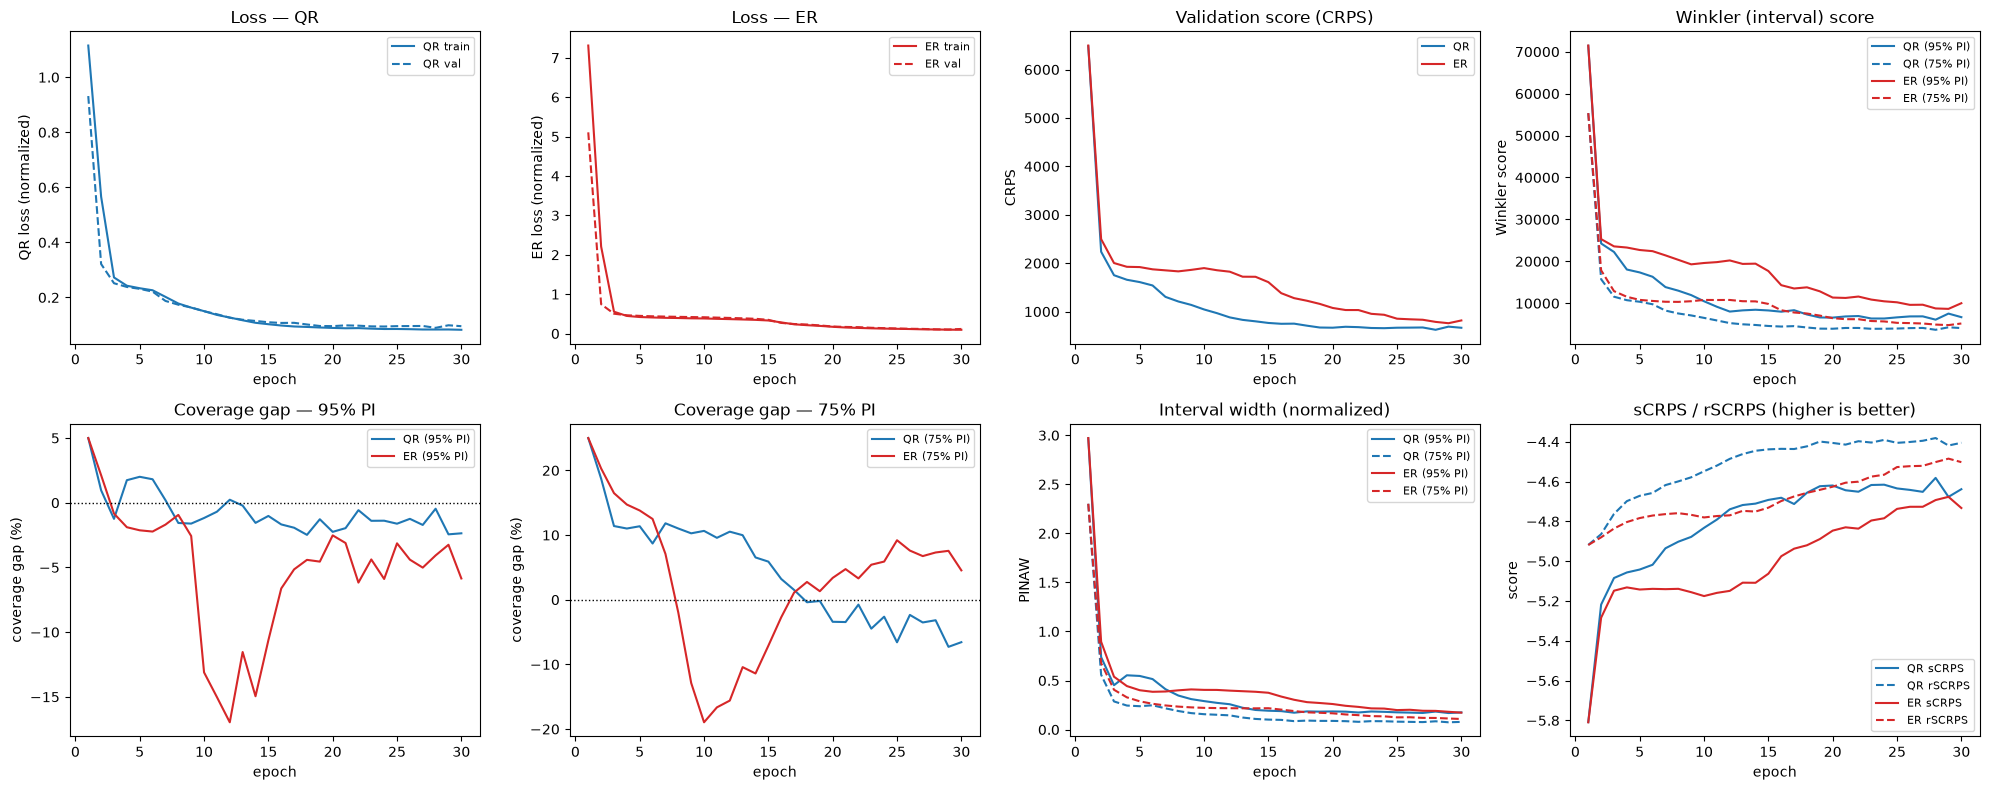

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
models = [('QR', fc_qr, 'tab:blue'), ('ER', fc_er, 'tab:red')]

for label, m, color in models:
    ep = np.arange(1, len(m.loss_log) + 1)
    ax = axes[0, 0] if label == 'QR' else axes[0, 1]
    ax.plot(ep, m.loss_log, color=color, label=f'{label} train')
    ax.plot(ep, m.val_log_aggregated['mean']['loss'], color=color, linestyle='--', label=f'{label} val')
    ax.set_xlabel('epoch'); ax.set_ylabel(f'{label} loss (normalized)')
    ax.set_title(f'Loss — {label}'); ax.legend(fontsize=8)

    axes[0, 2].plot(ep, m.val_log_aggregated['mean']['val_score'], color=color, label=label)

    # first WinklerScore/CoverageGap/PINAW occurrence = alpha=0.05 (95% PI); the '_2'
    # suffix is _criteria_field_names deduplicating the second occurrence = alpha=0.25 (75% PI)
    axes[0, 3].plot(ep, m.val_log_aggregated['mean']['WinklerScore'], color=color, linestyle='-', label=f'{label} (95% PI)')
    axes[0, 3].plot(ep, m.val_log_aggregated['mean']['WinklerScore_2'], color=color, linestyle='--', label=f'{label} (75% PI)')
    axes[1, 0].plot(ep, m.val_log_aggregated['mean']['CoverageGap'] * 100, color=color, label=f'{label} (95% PI)')
    axes[1, 1].plot(ep, m.val_log_aggregated['mean']['CoverageGap_2'] * 100, color=color, label=f'{label} (75% PI)')
    axes[1, 2].plot(ep, m.val_log_aggregated['mean']['PINAW'], color=color, linestyle='-', label=f'{label} (95% PI)')
    axes[1, 2].plot(ep, m.val_log_aggregated['mean']['PINAW_2'], color=color, linestyle='--', label=f'{label} (75% PI)')
    axes[1, 3].plot(ep, m.val_log_aggregated['mean']['SCRPS'], color=color, linestyle='-', label=f'{label} sCRPS')
    axes[1, 3].plot(ep, m.val_log_aggregated['mean']['RSCRPS'], color=color, linestyle='--', label=f'{label} rSCRPS')

axes[0, 2].set_xlabel('epoch'); axes[0, 2].set_ylabel('CRPS'); axes[0, 2].set_title('Validation score (CRPS)'); axes[0, 2].legend(fontsize=8)
axes[0, 3].set_xlabel('epoch'); axes[0, 3].set_ylabel('Winkler score'); axes[0, 3].set_title('Winkler (interval) score'); axes[0, 3].legend(fontsize=8)
axes[1, 0].axhline(0.0, color='black', lw=1, linestyle=':'); axes[1, 0].set_xlabel('epoch'); axes[1, 0].set_ylabel('coverage gap (%)'); axes[1, 0].set_title('Coverage gap — 95% PI'); axes[1, 0].legend(fontsize=8)
axes[1, 1].axhline(0.0, color='black', lw=1, linestyle=':'); axes[1, 1].set_xlabel('epoch'); axes[1, 1].set_ylabel('coverage gap (%)'); axes[1, 1].set_title('Coverage gap — 75% PI'); axes[1, 1].legend(fontsize=8)
axes[1, 2].set_xlabel('epoch'); axes[1, 2].set_ylabel('PINAW'); axes[1, 2].set_title('Interval width (normalized)'); axes[1, 2].legend(fontsize=8)
axes[1, 3].set_xlabel('epoch'); axes[1, 3].set_ylabel('score'); axes[1, 3].set_title('sCRPS / rSCRPS (higher is better)'); axes[1, 3].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Evaluation on `test_source` and `val_source`

In [6]:
from src.data.timeseries_dataset import TimeSeriesDataset

def evaluate(source):
    preds_qr = fc_qr.predict(source, batch_size=256)  # (n_windows, horizon, len(LEVELS))
    preds_er = fc_er.predict(source, batch_size=256)

    # target_col doesn't affect which windows get built (only x_h/x_f NaN does), so this
    # dataset covers the exact same windows as predict()'s internal one — built here only
    # to read off the (source_idx, t) index for date alignment, not to run the model
    ds = TimeSeriesDataset(
        sources=[source],
        seq_len=SEQ_LEN,
        horizon=HORIZON,
        historic_cols=HISTORIC_COLS,
        future_cols=[],
        norm_stats=fc_qr.norm_stats,
        target_col=TARGET_COL,
    )
    df = _read_1d_df(source)
    t_values = np.array([t for _, t in ds._index])
    y_true = np.stack([df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_values])
    return preds_qr, preds_er, y_true, t_values, df

preds_qr, preds_er, y_true, t_values, test_df = evaluate(test_source)
preds_qr_val, preds_er_val, y_true_val, t_values_val, val_df = evaluate(val_source)

# channel order matches sorted(LEVELS) — both fc_qr.output_levels and fc_er.output_levels
# (LO95/HI95/LO75/HI75/CENTER, defined in the data-setup cell, index into this order)
assert fc_qr.output_levels == LEVELS and fc_er.output_levels == LEVELS

print(f'Evaluated {y_true.shape[0]} windows (test) / {y_true_val.shape[0]} windows (val) over a {y_true.shape[1]}-day horizon')


Evaluated 1789 windows (test) / 1789 windows (val) over a 7-day horizon


## Fan chart

Observed vs. predicted at lead=1, with the 95% PI (light band) and 75% PI
(darker band) plus the center line (QR: median, ER: mean) — side by side for
the two models over the same period and y-axis limits.


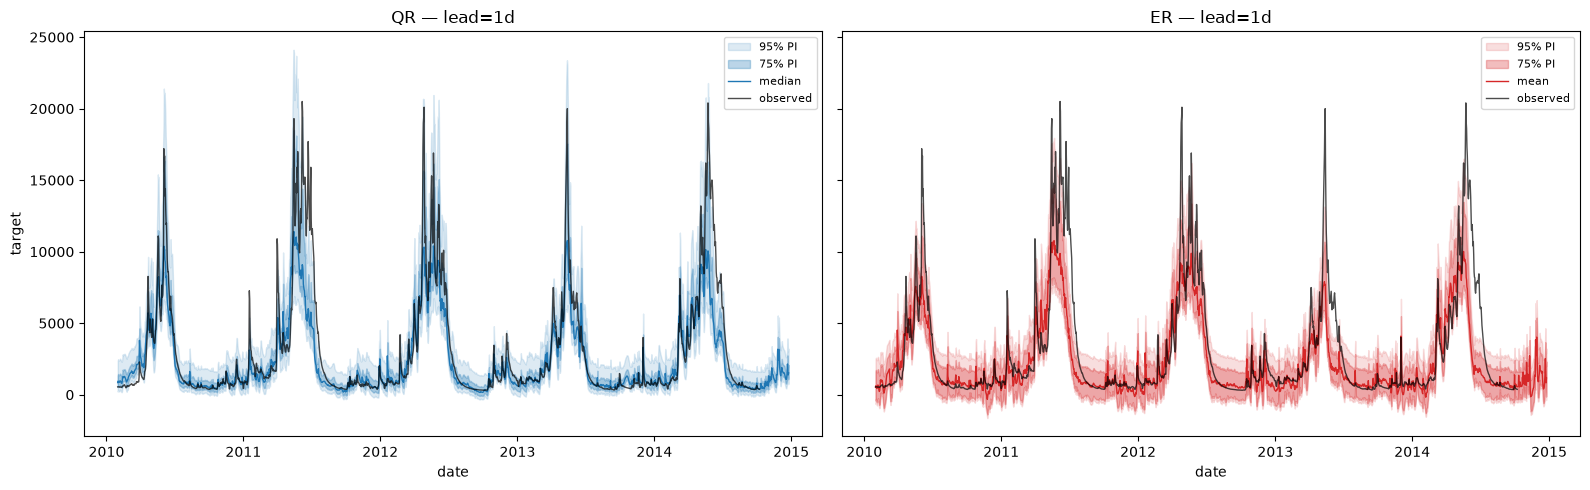

In [7]:
LEAD = 1
dates = test_df.index[t_values + SEQ_LEN + (LEAD - 1)]
y_obs = y_true[:, LEAD - 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, label, preds, color in [(axes[0], 'QR', preds_qr, 'tab:blue'), (axes[1], 'ER', preds_er, 'tab:red')]:
    p = preds[:, LEAD - 1, :]  # (n_windows, len(LEVELS))
    ax.fill_between(dates, p[:, LO95], p[:, HI95], color=color, alpha=0.15, label='95% PI')
    ax.fill_between(dates, p[:, LO75], p[:, HI75], color=color, alpha=0.3, label='75% PI')
    ax.plot(dates, p[:, CENTER], color=color, lw=1, label='median' if label == 'QR' else 'mean')
    ax.plot(dates, y_obs, color='black', lw=1, alpha=0.7, label='observed')
    ax.set_xlabel('date'); ax.set_title(f'{label} — lead={LEAD}d')
    ax.legend(fontsize=8)

axes[0].set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()


## Coverage gap / PINAW vs. lead time

Does calibration hold up as far-ahead predictions get harder — and does it hold up
out-of-sample? Coverage gap (`CoverageGap`, `src/utils/scores_and_losses.py`,
shown as a percentage): 0% is perfect calibration, positive is over-covered,
negative is under-covered. Same NaN-masking pattern as `check.ipynb`'s "NSE vs.
lead time" cell, computed per lead via the metric classes directly (`bind_levels`
once per model, reused across leads), on both `test_source` (solid) and
`val_source` (dashed) — a gap between the two would flag overfitting to
validation.


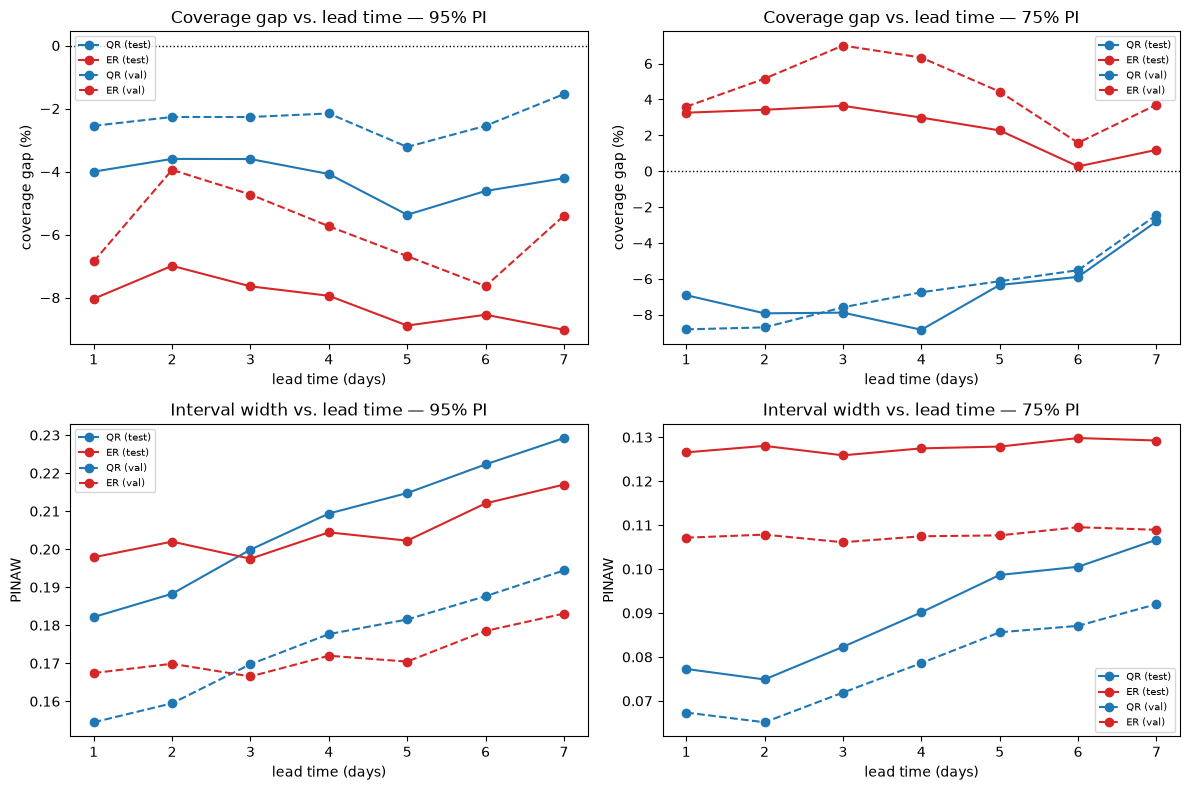

In [8]:
def coverage_gap_pinaw_per_lead(preds, y_true_arr, output_kind, alpha):
    gap = CoverageGap(alpha=alpha)
    pinaw = PINAW(alpha=alpha)
    gap.bind_levels(output_kind, LEVELS)
    pinaw.bind_levels(output_kind, LEVELS)
    gap_vals, pinaw_vals = [], []
    for lead in range(HORIZON):
        yt = y_true_arr[:, lead]
        yp = preds[:, lead, :]
        mask = ~np.isnan(yt)
        yt_t = torch.tensor(yt[mask])[:, None]
        yp_t = torch.tensor(yp[mask])
        gap_vals.append(gap(yp_t, yt_t).item() * 100)  # fraction -> percentage
        pinaw_vals.append(pinaw(yp_t, yt_t).item())
    return gap_vals, pinaw_vals

leads = np.arange(1, HORIZON + 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

datasets = [
    ('test', preds_qr, preds_er, y_true, '-'),
    ('val', preds_qr_val, preds_er_val, y_true_val, '--'),
]
for split, p_qr, p_er, yt_arr, ls in datasets:
    for label, preds, kind, color in [('QR', p_qr, 'quantile', 'tab:blue'), ('ER', p_er, 'expectile', 'tab:red')]:
        gap95, pinaw95 = coverage_gap_pinaw_per_lead(preds, yt_arr, kind, 0.05)
        gap75, pinaw75 = coverage_gap_pinaw_per_lead(preds, yt_arr, kind, 0.25)
        lbl = f'{label} ({split})'
        axes[0, 0].plot(leads, gap95, marker='o', color=color, linestyle=ls, label=lbl)
        axes[0, 1].plot(leads, gap75, marker='o', color=color, linestyle=ls, label=lbl)
        axes[1, 0].plot(leads, pinaw95, marker='o', color=color, linestyle=ls, label=lbl)
        axes[1, 1].plot(leads, pinaw75, marker='o', color=color, linestyle=ls, label=lbl)

axes[0, 0].axhline(0.0, color='black', lw=1, linestyle=':')
axes[0, 0].set_xlabel('lead time (days)'); axes[0, 0].set_ylabel('coverage gap (%)'); axes[0, 0].set_title('Coverage gap vs. lead time — 95% PI'); axes[0, 0].legend(fontsize=7)
axes[0, 1].axhline(0.0, color='black', lw=1, linestyle=':')
axes[0, 1].set_xlabel('lead time (days)'); axes[0, 1].set_ylabel('coverage gap (%)'); axes[0, 1].set_title('Coverage gap vs. lead time — 75% PI'); axes[0, 1].legend(fontsize=7)
axes[1, 0].set_xlabel('lead time (days)'); axes[1, 0].set_ylabel('PINAW'); axes[1, 0].set_title('Interval width vs. lead time — 95% PI'); axes[1, 0].legend(fontsize=7)
axes[1, 1].set_xlabel('lead time (days)'); axes[1, 1].set_ylabel('PINAW'); axes[1, 1].set_title('Interval width vs. lead time — 75% PI'); axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()


## Quantitative summary on `test_source`

Same probabilistic scores as training's `validation_logging_criteria`, computed
directly on the full pooled test-set array via the metric classes themselves
(same pattern `check.ipynb`'s "NSE vs. lead time" cell uses) — an explicit NaN
mask is applied first, since metric classes don't skip NaN the way
`np.nanmean` does.


In [9]:
def summarize(preds, output_kind, label):
    mask = ~np.isnan(y_true)
    yp = torch.tensor(preds[mask])       # (N, len(LEVELS))
    yt = torch.tensor(y_true[mask])[:, None]  # (N, 1)

    metrics = [
        ('MAE', MAE()),
        ('CRPS', CRPS()),
        ('SCRPS', SCRPS()),
        (f'rSCRPS (c={C_RSCRPS})', RSCRPS(c=C_RSCRPS)),
        ('Winkler Score (alpha=0.05)', WinklerScore(alpha=0.05)),
        ('PICP (alpha=0.05)', PICP(alpha=0.05)),
        ('PINAW (alpha=0.05)', PINAW(alpha=0.05)),
        ('Winkler Score (alpha=0.25)', WinklerScore(alpha=0.25)),
        ('PICP (alpha=0.25)', PICP(alpha=0.25)),
        ('PINAW (alpha=0.25)', PINAW(alpha=0.25)),
    ]

    rows = {}
    for row_label, m in metrics:
        m.bind_levels(output_kind, LEVELS)
        rows[row_label] = m(yp, yt).item()

    print(f'--- {label} ---')
    for k, v in rows.items():
        print(f'{k:32s} {v:.4f}')
    print()

summarize(preds_qr, 'quantile', 'QR')
summarize(preds_er, 'expectile', 'ER')


--- QR ---
MAE                              1056.0923
CRPS                             792.4180
SCRPS                            -4.7877
rSCRPS (c=2621.0)                -4.4756
Winkler Score (alpha=0.05)       8327.3216
PICP (alpha=0.05)                0.9079
PINAW (alpha=0.05)               0.2065
Winkler Score (alpha=0.25)       4947.2568
PICP (alpha=0.25)                0.6834
PINAW (alpha=0.25)               0.0901

--- ER ---
MAE                              1246.8011
CRPS                             1017.1721
SCRPS                            -4.9077
rSCRPS (c=2621.0)                -4.5560
Winkler Score (alpha=0.05)       15751.7984
PICP (alpha=0.05)                0.8685
PINAW (alpha=0.05)               0.2047
Winkler Score (alpha=0.25)       6760.4985
PICP (alpha=0.25)                0.7743
PINAW (alpha=0.25)               0.1278



## Coverage gap by calendar month vs. time

Same coverage indicator as `CoverageGap` (whether the observation falls inside
the `[LO95, HI95]` channels, minus the nominal 95% coverage), but now viewed as
a block value per calendar month instead of aggregated per lead — at lead
times 1, 4, and 7 days on `test_source`, for QR and ER. Below each panel, the
observed `TARGET_COL` series for that same lead/dates is plotted with its
background shaded per month by that month's `|coverage gap|` (green = well
calibrated, red = far off) so regimes where calibration breaks down can be
read directly against what was actually happening in the series. QR and ER
get their own hydrograph row since each model's calibration differs
month-to-month.


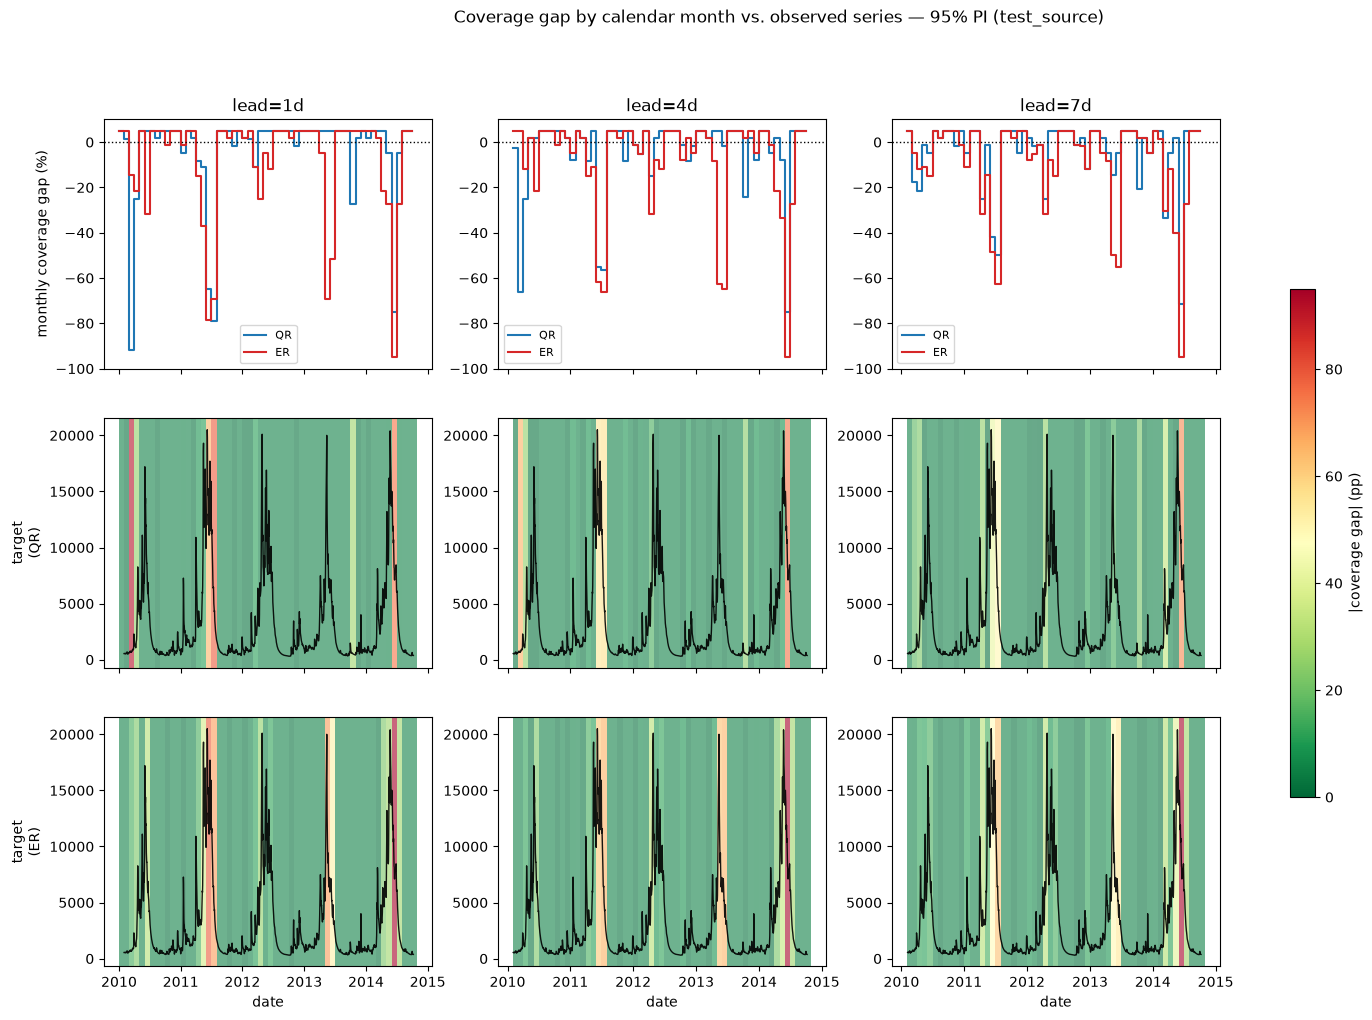

In [10]:
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

LEADS_MA = [1, 4, 7]
CMAP = plt.get_cmap('RdYlGn_r')  # 0 -> green (well calibrated), large |gap| -> red

def monthly_coverage_gap(preds, y_true_arr, lead, dates_all):
    yt = y_true_arr[:, lead - 1]
    yp = preds[:, lead - 1, :]
    mask = ~np.isnan(yt)
    lower, upper = yp[mask, LO95], yp[mask, HI95]
    indicator = ((yt[mask] >= lower) & (yt[mask] <= upper)).astype(float)
    gap = pd.Series(indicator, index=dates_all[mask]).sort_index()
    return (gap.resample('MS').mean() - 0.95) * 100  # fraction -> percentage points, one value per month

def shade_months(ax, monthly, norm):
    for month_start, val in monthly.items():
        if pd.isna(val):
            continue
        ax.axvspan(month_start, month_start + pd.offsets.MonthBegin(1), color=CMAP(norm(abs(val))), alpha=0.6, lw=0)

# per-lead monthly gaps for both models, computed once and reused for both the top
# panel and the hydrograph shading below; also used to fix one color scale shared
# across every panel so panels stay comparable
dates_by_lead = {lead: test_df.index[t_values + SEQ_LEN + (lead - 1)] for lead in LEADS_MA}
monthly_by_lead = {
    lead: {
        'QR': monthly_coverage_gap(preds_qr, y_true, lead, dates_by_lead[lead]),
        'ER': monthly_coverage_gap(preds_er, y_true, lead, dates_by_lead[lead]),
    }
    for lead in LEADS_MA
}
vmax = np.nanmax([
    monthly.abs().max() for per_lead in monthly_by_lead.values() for monthly in per_lead.values()
])
norm = Normalize(vmin=0, vmax=vmax)

fig, axes = plt.subplots(3, 3, figsize=(18, 11), sharex='col')
for col, lead in enumerate(LEADS_MA):
    dates_all = dates_by_lead[lead]
    monthly = monthly_by_lead[lead]
    ax_gap, ax_qr, ax_er = axes[0, col], axes[1, col], axes[2, col]

    for label, color in [('QR', 'tab:blue'), ('ER', 'tab:red')]:
        m = monthly[label]
        ax_gap.step(m.index, m.values, where='post', color=color, label=label)
    ax_gap.axhline(0.0, color='black', lw=1, linestyle=':')
    ax_gap.set_title(f'lead={lead}d')
    ax_gap.legend(fontsize=8)

    y_obs = y_true[:, lead - 1]
    obs_mask = ~np.isnan(y_obs)
    for ax_row, label in [(ax_qr, 'QR'), (ax_er, 'ER')]:
        shade_months(ax_row, monthly[label], norm)
        ax_row.plot(dates_all[obs_mask], y_obs[obs_mask], color='black', lw=1, alpha=0.9)
        if col == 0:
            ax_row.set_ylabel(f'{TARGET_COL}\n({label})')
    ax_er.set_xlabel('date')

axes[0, 0].set_ylabel('monthly coverage gap (%)')
sm = ScalarMappable(norm=norm, cmap=CMAP)
sm.set_array([])
# spans every row (not just the hydrograph rows) so the colorbar shrinks all three
# rows' widths equally -- otherwise row 0 stays full-width while rows 1-2 shrink,
# and the columns no longer line up vertically
fig.colorbar(sm, ax=axes, label='|coverage gap| (pp)', shrink=0.6)
fig.suptitle('Coverage gap by calendar month vs. observed series — 95% PI (test_source)')
plt.show()
